In [1]:
import os
import random
import time
import numpy as np
from ase.io import read, write
from quests.descriptor import get_descriptors
from quests.entropy import perfect_entropy, diversity, delta_entropy, approx_delta_entropy

In [19]:
# get a subset of mptrj
random.seed(8)

def random_sample_from_directory(directory, sample_size):
    files = sorted(os.listdir(directory))  # Get all files
    files = [f for f in files if os.path.isfile(os.path.join(directory, f))]  # Filter only files
    sample = random.sample(files, min(sample_size, len(files)))  # Pick random sample
    return sample

# Example usage
data_dir = "/data/shared/MPTrj/original"
sample_size = 500  # Change to the desired number of files

random_files = random_sample_from_directory(data_dir, sample_size)
print(len(random_files))
print(random_files[0])

500
mp-1218041.extxyz


In [20]:
# save the subset to a file
structures_1 = []
for filename in random_files:
    if filename.endswith(".extxyz"):
        filepath = os.path.join(data_dir, filename)
        atoms = read(filepath, index=":")  # Load all frames in case of trajectory files
        structures_1.extend(atoms)  # Add structures to list

In [2]:
# reload the structures
# Reload saved structures
structures = read("mptrj_without_subset.extxyz", index=":")  # Use "mptrj_combined.traj" if using traj format
print(f"Loaded {len(structures)} structures from file.")

Loaded 1575077 structures from file.


In [ ]:
# dset = read("mptrj_subset_500.extxyz", index=":")
# x = get_descriptors(dset, k=32, cutoff=5.0)
# h = 0.015
# batch_size = 10000
# H = perfect_entropy(x, h=h, batch_size=batch_size)
# D = diversity(x, h=h, batch_size=batch_size) 

In [21]:
# dset_x = read("mptrj_combined.extxyz", index=":")
# dset_y = read("mptrj_subset_500.extxyz", index=":")
dset_y = read("/data/shared/MPTrj/original/mp-1245902.extxyz", index=":")

k, cutoff = 32, 5.0

t0 = time.time()
y = get_descriptors(dset_y, k=k, cutoff=cutoff)
t1 = time.time()
print(f"y get descriptors took {t1-t0:.2f} seconds")

t2 = time.time()
x = get_descriptors(structures_1, k=k, cutoff=cutoff)
t3 = time.time()
print(f"x get descriptors took {t3-t2:.2f} seconds")

# computes dH (Y | X)
t4 = time.time()
dH = delta_entropy(y, x, h=0.015)
t5 = time.time()
print(f"dH took {t5-t4:.2f} seconds")

# this didn't even finish in 45+ min

y get descriptors took 0.55 seconds
x get descriptors took 250.13 seconds
dH took 1.25 seconds


In [17]:
# approximate version
# dset_y = read("mptrj_subset_500.extxyz", index=":")
dset_y = read("/data/shared/MPTrj/original/mp-1245902.extxyz", index=":")

k, cutoff = 32, 5.0

t0 = time.time()
y = get_descriptors(dset_y, k=k, cutoff=cutoff)
t1 = time.time()
print(f"y get descriptors took {t1-t0:.2f} seconds")

t2 = time.time()
x = get_descriptors(structures_1, k=k, cutoff=cutoff)
t3 = time.time()
print(f"x get descriptors took {t3-t2:.2f} seconds")

# computes dH (Y | X)
t4 = time.time()
dH = approx_delta_entropy(y, x, h=0.015, n=5, graph_neighbors=10)
t5 = time.time()
print(f"approximate dH took {t5-t4:.2f} seconds")

y get descriptors took 0.40 seconds
x get descriptors took 26.85 seconds
approximate dH took 50.91 seconds


/home/christine/quests/quests/entropy.py:457: RuntimeWarning: divide by zero encountered in log
  return -np.log(p_y)


In [23]:
y.shape

(264, 63)

In [24]:
x.shape

(171170, 63)

In [25]:
y[0]

array([4.03035641e-01, 3.95964354e-01, 3.38760674e-01, 3.36937308e-01,
       1.04747288e-01, 9.86256674e-02, 9.79066119e-02, 8.29471201e-02,
       8.17154944e-02, 7.14362413e-02, 7.08715767e-02, 5.50772101e-02,
       5.48379272e-02, 5.37284836e-02, 4.39869203e-02, 4.02265117e-02,
       3.14730220e-02, 2.22644117e-02, 1.88715979e-02, 1.37889031e-02,
       1.14944745e-02, 5.42683061e-03, 5.01474878e-03, 3.79272504e-03,
       2.45042634e-03, 1.92584656e-03, 8.82082502e-04, 4.22756188e-04,
       8.36593172e-05, 2.37938525e-06, 0.00000000e+00, 0.00000000e+00,
       1.16332732e-01, 9.19347331e-02, 7.96995610e-02, 7.04183877e-02,
       6.27821535e-02, 5.55173084e-02, 4.98623997e-02, 4.55257967e-02,
       4.20534834e-02, 3.84180248e-02, 3.59116793e-02, 3.39121036e-02,
       3.19731385e-02, 3.00741680e-02, 2.81632859e-02, 2.58687027e-02,
       2.33218763e-02, 1.99528951e-02, 1.73445605e-02, 1.54048763e-02,
       1.27284247e-02, 1.04696527e-02, 8.88034608e-03, 7.34660355e-03,
      

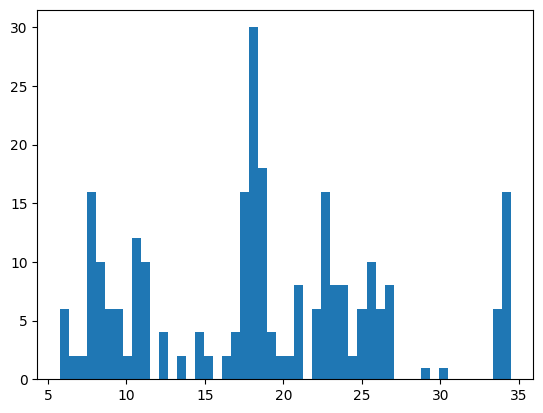

In [29]:
# make a histogram of the values in dH using pyplot
import matplotlib.pyplot as plt

plt.hist(dH, bins=50)
plt.show()



In [30]:
np.save('y.npy', y)
np.save('x.npy', x)

In [31]:
new_y = np.load('y.npy')
new_x = np.load('x.npy')

In [33]:
new_x.shape

(171170, 63)

In [35]:
print(f"x get descriptors took {(t3-t2) / 60 / 60:.4f} hours")

x get descriptors took 0.0695 hours


In [38]:
dH.shape

(264,)

In [6]:
total = 0
for i in range(-3, 2):
    total += abs(3 + 4 * np.cos(2 * np.pi * i / 5) + 6 * np.cos(4 * np.pi * i / 5))** 2

print(total)

175.0


In [2]:
print("Loading 0th descriptor")
x_desc_0 = np.load("mptrj_without_subset_descriptors_0.npy")

print("Loading 1st descriptor")
x_desc_1 = np.load("mptrj_without_subset_descriptors_1.npy")

print("Loading 2nd descriptor")
x_desc_2 = np.load("mptrj_without_subset_descriptors_2.npy")

print("Loading 3rd descriptor")
x_desc_3 = np.load("mptrj_without_subset_descriptors_3.npy")

print("Loading y descriptor")
y_desc = np.load("mptrj_subset_descriptors.npy")

x_desc = np.vstack((x_desc_0, x_desc_1, x_desc_2, x_desc_3))

Loading 0th descriptor
Loading 1st descriptor
Loading 2nd descriptor
Loading 3rd descriptor
Loading y descriptor


In [8]:
x_desc.shape

(49134625, 63)

In [9]:
y_desc.shape

(161035, 63)

In [ ]:
dH_approx = approx_delta_entropy(y_desc, x_desc, h=0.015, n=5, graph_neighbors=10)
dH_approx.shape